In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, f1_score, average_precision_score,
    classification_report, precision_score, recall_score,
    precision_recall_curve
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

###############################################################################

## 1. UCI Data

###############################################################################


In [3]:
# ============================================================
# SECTION B: UCI_data  (BEED + Bangalore EEG Epilepsy Dataset)
# EEG dataset for epilepsy/seizure classification
# ============================================================

print("\n" + "="*70)
print("DATASET 1: UCI_data (BEED + Bangalore EEG Epilepsy Dataset)")
print("="*70)

# ── Load ─────────────────────────────────────────────────────
UCI_data = pd.read_csv(
    "/content/drive/MyDrive/AI_work/ims/Data Mining/Major Project/data/1.UCI-beed_+bangalore+eeg+epilepsy+dataset/BEED_Data.csv"
)


# ── Basic Information ───────────────────────────────────────
print(f"\nShape: {UCI_data.shape}")


DATASET 1: UCI_data (BEED + Bangalore EEG Epilepsy Dataset)

Shape: (8000, 17)


In [4]:
# Checking null values
UCI_data.isnull().sum().sum()

np.int64(0)

In [5]:
# ── Setup ─────────────────────────────────────────────────────────────────────

X = UCI_data.drop('y', axis=1)
y = (UCI_data['y'] == 1).astype(int)  # binary: seizure vs non-seizure

### PIPELINE A

In [6]:
# ── Pipeline A: Normalization → Noise Removal → Feature Selection ─────────────
# FIX: Split FIRST, then fit_transform on train only to prevent data leakage

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def apply_pipeline_A(X_tr, y_tr, X_te):
    """Pipeline A: MinMax normalize → clip outliers → SelectKBest(k=8).
    Fits only on training data to prevent data leakage."""
    # Step 1: Normalization (MinMax)
    scaler = MinMaxScaler()
    X_tr_norm = scaler.fit_transform(X_tr)
    X_te_norm = scaler.transform(X_te)

    # Step 2: Noise Removal (clip extreme outliers beyond 3 std of TRAIN)
    mean, std = X_tr_norm.mean(axis=0), X_tr_norm.std(axis=0)
    X_tr_den = np.clip(X_tr_norm, mean - 3*std, mean + 3*std)
    X_te_den = np.clip(X_te_norm, mean - 3*std, mean + 3*std)

    # Step 3: Feature Selection (top 8 features via ANOVA F-score, fit on train)
    selector = SelectKBest(f_classif, k=8)
    X_tr_sel = selector.fit_transform(X_tr_den, y_tr)
    X_te_sel = selector.transform(X_te_den)

    return X_tr_sel, X_te_sel

X_train_A, X_test_A = apply_pipeline_A(X_train_raw, y_train_raw, X_test_raw)
# Keep X_A (full dataset version) for cross-validation cells that need it
# We refit on full X only for CV — split versions used for all hold-out evaluations
scaler_full = MinMaxScaler()
X_norm_full = scaler_full.fit_transform(X)
mean_f, std_f = X_norm_full.mean(axis=0), X_norm_full.std(axis=0)
X_den_full = np.clip(X_norm_full, mean_f - 3*std_f, mean_f + 3*std_f)
sel_full = SelectKBest(f_classif, k=8)
X_A = sel_full.fit_transform(X_den_full, y)  # used only for CV

print(f"Pipeline A — train shape: {X_train_A.shape} | test shape: {X_test_A.shape}")
print(f"Pipeline A output shape (full, CV only): {X_A.shape}")


Pipeline A — train shape: (6400, 8) | test shape: (1600, 8)
Pipeline A output shape (full, CV only): (8000, 8)


In [7]:
# ── Pipeline B: Feature Extraction → StandardScaler → PCA ───────────────────
# FIX: fit_transform on train only; PCA n_components=0.95 (consistent with MIT/Bonn)

def apply_pipeline_B(X_tr, X_te):
    """Pipeline B: Standardize → extract statistical features → PCA(0.95).
    Fits only on training data to prevent data leakage."""
    # Step 1: Standardization
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    # Step 2: Feature Extraction (statistical features per sample)
    def extract_stats(Xm):
        df = pd.DataFrame(Xm)
        return np.column_stack([
            df.mean(axis=1), df.std(axis=1),
            df.max(axis=1),  df.min(axis=1),
            df.skew(axis=1), df.kurt(axis=1)
        ])

    X_tr_ext = extract_stats(X_tr_sc)
    X_te_ext = extract_stats(X_te_sc)

    # Step 3: PCA — 95% variance (FIX: was 0.9999, now consistent with MIT/Bonn)
    pca = PCA(n_components=0.95, random_state=42)
    X_tr_pca = pca.fit_transform(X_tr_ext)
    X_te_pca = pca.transform(X_te_ext)
    print(f"  Pipeline B → PCA components retained: {pca.n_components_}")

    return X_tr_pca, X_te_pca

X_train_B, X_test_B = apply_pipeline_B(X_train_raw, X_test_raw)

# X_B for CV (fit on full X — acceptable for cross_val_score which does its own splits)
scaler_B_full = StandardScaler()
X_sc_full = scaler_B_full.fit_transform(X)
df_full = pd.DataFrame(X_sc_full)
X_ext_full = np.column_stack([
    df_full.mean(axis=1), df_full.std(axis=1),
    df_full.max(axis=1),  df_full.min(axis=1),
    df_full.skew(axis=1), df_full.kurt(axis=1)
])
pca_B_full = PCA(n_components=0.95, random_state=42)
X_B = pca_B_full.fit_transform(X_ext_full)  # used only for CV

print(f"Pipeline B — train shape: {X_train_B.shape} | test shape: {X_test_B.shape}")
print(f"Pipeline B output shape (full, CV only): {X_B.shape}")


  Pipeline B → PCA components retained: 4
Pipeline B — train shape: (6400, 4) | test shape: (1600, 4)
Pipeline B output shape (full, CV only): (8000, 4)


### Applying Logistic Regression

In [8]:
# FIX: Renamed evaluate() -> evaluate_uci() to avoid silent overwrite by
# the different-signature evaluate() defined later (Cell 28) for MIT/Bonn
def evaluate_uci(X_tr, y_tr, X_te, y_te, pipeline_name):
    """Evaluate logistic regression on pre-split UCI data. Returns fitted model."""
    model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    model.fit(X_tr, y_tr)

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc    = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_te, y_proba)

    print(f"\n=== {pipeline_name} — Baseline Logistic Regression ===")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  PR-AUC   : {pr_auc:.4f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Non-Seizure','Seizure'], zero_division=0)}")

    return model, y_pred, y_te  # FIX: also return y_pred and y_te for confusion matrix


In [9]:
print("\n--- Baseline Results ---")
model_A, y_pred_A_test, y_test_A_cm = evaluate_uci(
    X_train_A, y_train_raw, X_test_A, y_test_raw, "Pipeline A"
)



--- Baseline Results ---

=== Pipeline A — Baseline Logistic Regression ===
  Accuracy : 0.6206
  F1-Score : 0.4385
  PR-AUC   : 0.3341

              precision    recall  f1-score   support

 Non-Seizure       0.82      0.63      0.71      1200
     Seizure       0.35      0.59      0.44       400

    accuracy                           0.62      1600
   macro avg       0.59      0.61      0.58      1600
weighted avg       0.70      0.62      0.64      1600



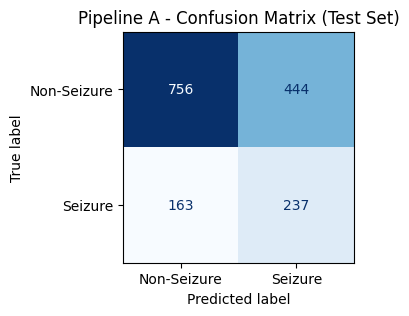

In [10]:
# FIX: Confusion matrix now uses held-out TEST set only (not full dataset)
cm_A = confusion_matrix(y_test_A_cm, y_pred_A_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_A,
    display_labels=['Non-Seizure', 'Seizure']
)
fig, ax = plt.subplots(figsize=(4, 3))
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
plt.title("Pipeline A - Confusion Matrix (Test Set)")
plt.savefig('Confusion_matrix_PipelineA.png', dpi=150, bbox_inches='tight')  # FIX: typo 'Pipline' -> 'Pipeline'
plt.show()


In [11]:
model_B, y_pred_B_test, y_test_B_cm = evaluate_uci(
    X_train_B, y_train_raw, X_test_B, y_test_raw, "Pipeline B"
)



=== Pipeline B — Baseline Logistic Regression ===
  Accuracy : 0.4600
  F1-Score : 0.4178
  PR-AUC   : 0.2565

              precision    recall  f1-score   support

 Non-Seizure       0.83      0.35      0.50      1200
     Seizure       0.29      0.78      0.42       400

    accuracy                           0.46      1600
   macro avg       0.56      0.56      0.46      1600
weighted avg       0.69      0.46      0.48      1600



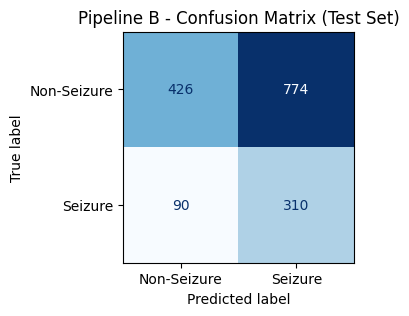

In [12]:
cm_B = confusion_matrix(y_test_B_cm, y_pred_B_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_B,
    display_labels=['Non-Seizure', 'Seizure']
)
fig, ax = plt.subplots(figsize=(4, 3))
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
plt.title("Pipeline B - Confusion Matrix (Test Set)")  # FIX: title before savefig
plt.savefig('Confusion_matrix_PipelineB.png', dpi=150, bbox_inches='tight')  # FIX: typo 'Pipline' -> 'Pipeline'
plt.show()


### Demonstrating Underfitting and overfitting

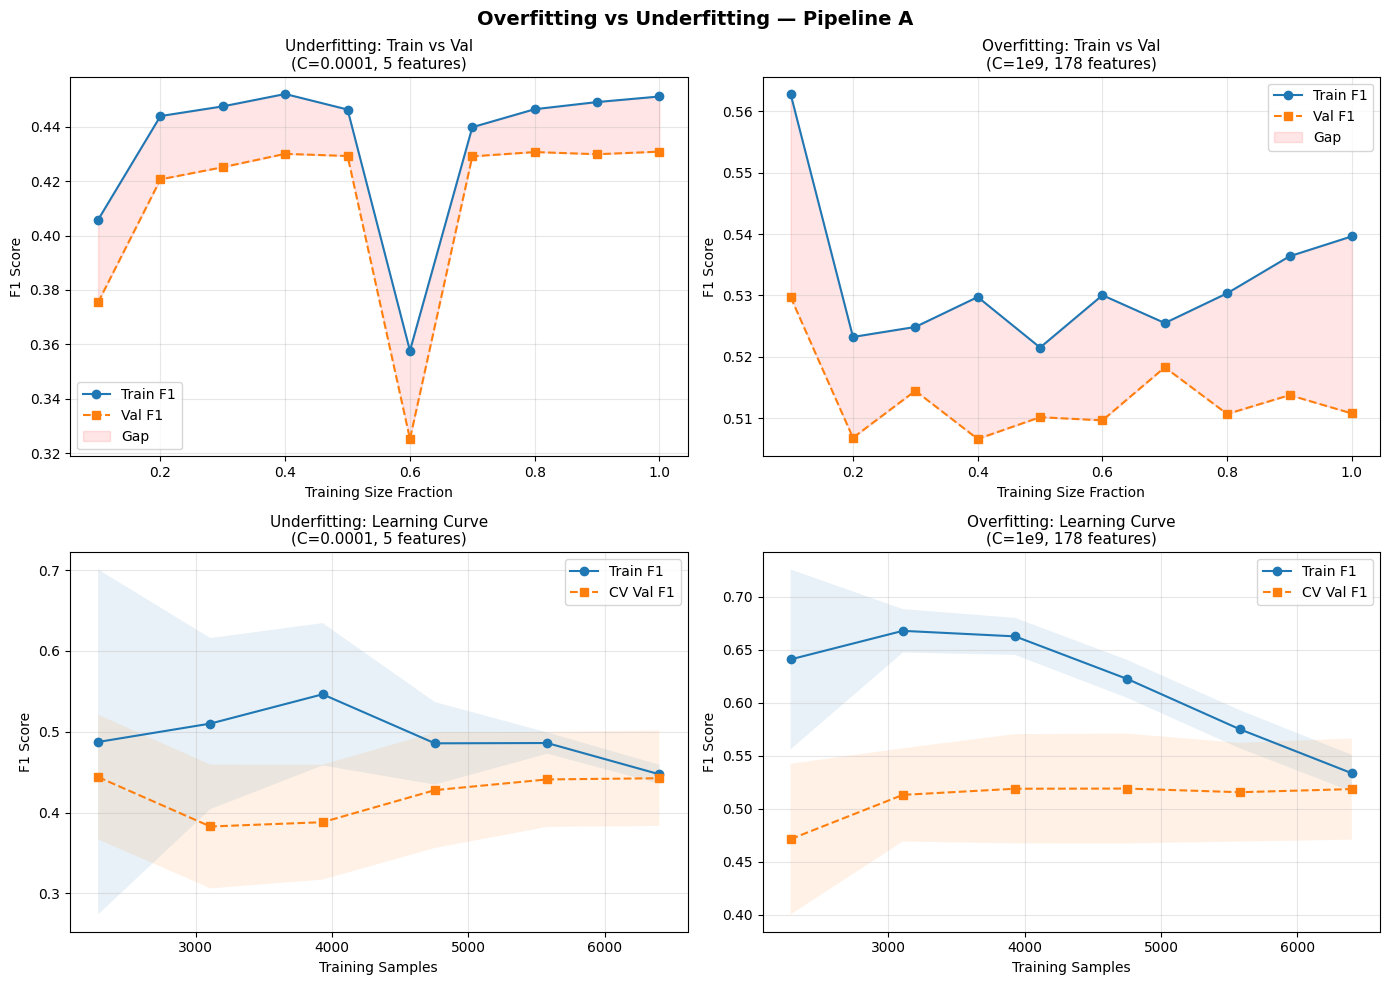

In [13]:
# ── Base split from Pipeline A ────────────────────────────────────────────────

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y, test_size=0.2, random_state=42, stratify=y
)

# ── Underfitting: C=0.0001 + only 5 features ─────────────────────────────────

selector_under = SelectKBest(f_classif, k=5)
X_under        = selector_under.fit_transform(X_A, y)
X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(
    X_under, y, test_size=0.2, random_state=42, stratify=y
)
model_under = LogisticRegression(C=0.0001, max_iter=1000, random_state=42,
                                  class_weight='balanced')

# ── Overfitting: C=1e9 + all 178 raw features ────────────────────────────────

X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)
model_over = LogisticRegression(C=1e9, max_iter=1000, random_state=42,
                                 class_weight='balanced')

# ── Helper: Training vs Validation Curve ─────────────────────────────────────

def plot_train_val(model, X_tr, y_tr, X_te, y_te, title, ax):
    fractions   = np.linspace(0.1, 1.0, 10)
    train_f1s, val_f1s = [], []

    for frac in fractions:
        n = max(10, int(len(X_tr) * frac))
        model.fit(X_tr[:n], y_tr[:n])
        train_f1s.append(f1_score(y_tr[:n], model.predict(X_tr[:n]), zero_division=0))
        val_f1s.append(f1_score(y_te,       model.predict(X_te),     zero_division=0))

    ax.plot(fractions, train_f1s, label='Train F1',      marker='o')
    ax.plot(fractions, val_f1s,   label='Val F1',        marker='s', linestyle='--')
    ax.fill_between(fractions, train_f1s, val_f1s, alpha=0.1, color='red', label='Gap')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Training Size Fraction')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

# ── Helper: Learning Curve ────────────────────────────────────────────────────

def plot_learning(model, X, y, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
    vl_mean, vl_std = val_scores.mean(1),   val_scores.std(1)

    ax.plot(train_sizes, tr_mean, label='Train F1', marker='o')
    ax.plot(train_sizes, vl_mean, label='CV Val F1', marker='s', linestyle='--')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.1)
    ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Overfitting vs Underfitting — Pipeline A', fontsize=14, fontweight='bold')

plot_train_val(model_under, X_tr_u, y_tr_u, X_te_u, y_te_u,
               'Underfitting: Train vs Val\n(C=0.0001, 5 features)', axes[0][0])

plot_train_val(model_over, X_tr_o, y_tr_o, X_te_o, y_te_o,
               'Overfitting: Train vs Val\n(C=1e9, 178 features)', axes[0][1])

plot_learning(model_under, X_under, y,
              'Underfitting: Learning Curve\n(C=0.0001, 5 features)', axes[1][0])

plot_learning(model_over, X.values, y,
              'Overfitting: Learning Curve\n(C=1e9, 178 features)', axes[1][1])

plt.tight_layout()
plt.savefig('overfit_underfit.png', dpi=150, bbox_inches='tight')
plt.show()

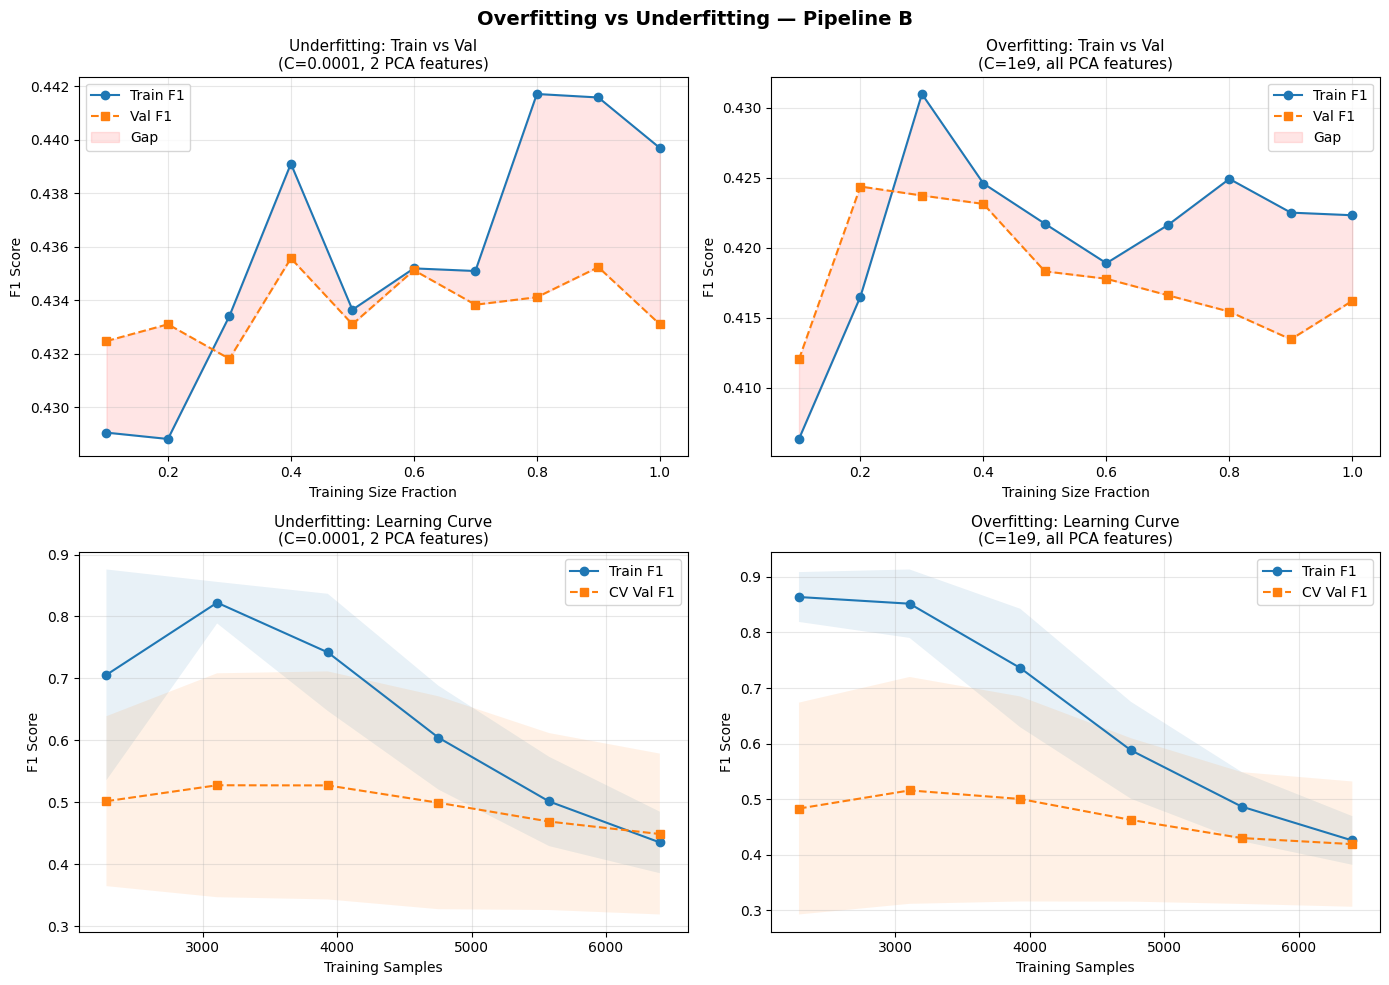

In [14]:
# ── Pipeline B split ──────────────────────────────────────────────────────────

X_tr_B, X_te_B, y_tr_B, y_te_B = train_test_split(
    X_B, y, test_size=0.2, random_state=42, stratify=y
)

# Underfitting: C=0.0001 + only 2 features (Pipeline B only has few PCA components)
n_under_B = min(2, X_B.shape[1])
X_under_B = X_B[:, :n_under_B]
X_tr_uB, X_te_uB, y_tr_uB, y_te_uB = train_test_split(
    X_under_B, y, test_size=0.2, random_state=42, stratify=y
)
model_under_B = LogisticRegression(C=0.0001, max_iter=1000, random_state=42,
                                    class_weight='balanced')

# Overfitting: C=1e9 + all PCA components
model_over_B = LogisticRegression(C=1e9, max_iter=1000, random_state=42,
                                   class_weight='balanced')

# ── Plot Pipeline B ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Overfitting vs Underfitting — Pipeline B', fontsize=14, fontweight='bold')

plot_train_val(model_under_B, X_tr_uB, y_tr_uB, X_te_uB, y_te_uB,
               f'Underfitting: Train vs Val\n(C=0.0001, {n_under_B} PCA features)', axes[0][0])

plot_train_val(model_over_B, X_tr_B, y_tr_B, X_te_B, y_te_B,
               'Overfitting: Train vs Val\n(C=1e9, all PCA features)', axes[0][1])

plot_learning(model_under_B, X_under_B, y,
              f'Underfitting: Learning Curve\n(C=0.0001, {n_under_B} PCA features)', axes[1][0])

plot_learning(model_over_B, X_B, y,
              'Overfitting: Learning Curve\n(C=1e9, all PCA features)', axes[1][1])

plt.tight_layout()
plt.savefig('overfit_underfit_B.png', dpi=150, bbox_inches='tight')
plt.show()

### Regularization

In [15]:
# ── Models: L1, L2, Elastic Net ───────────────────────────────────────────────

models = {
    'L1 (Lasso)' : LogisticRegression(penalty='l1', C=1.0, solver='liblinear',
                                       max_iter=1000, random_state=42, class_weight='balanced'),
    'L2 (Ridge)' : LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                       max_iter=1000, random_state=42, class_weight='balanced'),
    'Elastic Net': LogisticRegression(penalty='elasticnet', C=1.0, solver='saga',
                                       l1_ratio=0.5, max_iter=2000, random_state=42,
                                       class_weight='balanced'),
}

# ── Evaluation: Metrics + CV Stability ────────────────────────────────────────

def evaluate_regularization(X, y, pipeline_name):
    """Cross-validate each regularization model. X should be full dataset for CV."""
    results = {}

    for name, model in models.items():
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=-1)
        model.fit(X, y)

        # Sparsity: % of zero coefficients
        coef      = model.coef_.flatten()
        zero_pct  = np.mean(coef == 0) * 100
        n_nonzero = np.sum(coef != 0)

        results[name] = {
            'cv_mean'  : cv_scores.mean(),
            'cv_std'   : cv_scores.std(),
            'zero_pct' : zero_pct,
            'n_nonzero': n_nonzero,
            'coef'     : coef,
            'cv_scores': cv_scores
        }
        print(f"  {name:15s} | CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} "
              f"| Zero coefs: {zero_pct:.1f}% | Non-zero: {n_nonzero}")

    return results

print("=== Pipeline A ===")
results_A = evaluate_regularization(X_A, y, "Pipeline A")

print("\n=== Pipeline B ===")
results_B = evaluate_regularization(X_B, y, "Pipeline B")


=== Pipeline A ===
  L1 (Lasso)      | CV F1: 0.4371 ± 0.0820 | Zero coefs: 0.0% | Non-zero: 8
  L2 (Ridge)      | CV F1: 0.4477 ± 0.0770 | Zero coefs: 0.0% | Non-zero: 8
  Elastic Net     | CV F1: 0.4432 ± 0.0813 | Zero coefs: 12.5% | Non-zero: 7

=== Pipeline B ===
  L1 (Lasso)      | CV F1: 0.4186 ± 0.1123 | Zero coefs: 0.0% | Non-zero: 4
  L2 (Ridge)      | CV F1: 0.4192 ± 0.1129 | Zero coefs: 0.0% | Non-zero: 4
  Elastic Net     | CV F1: 0.4184 ± 0.1121 | Zero coefs: 0.0% | Non-zero: 4


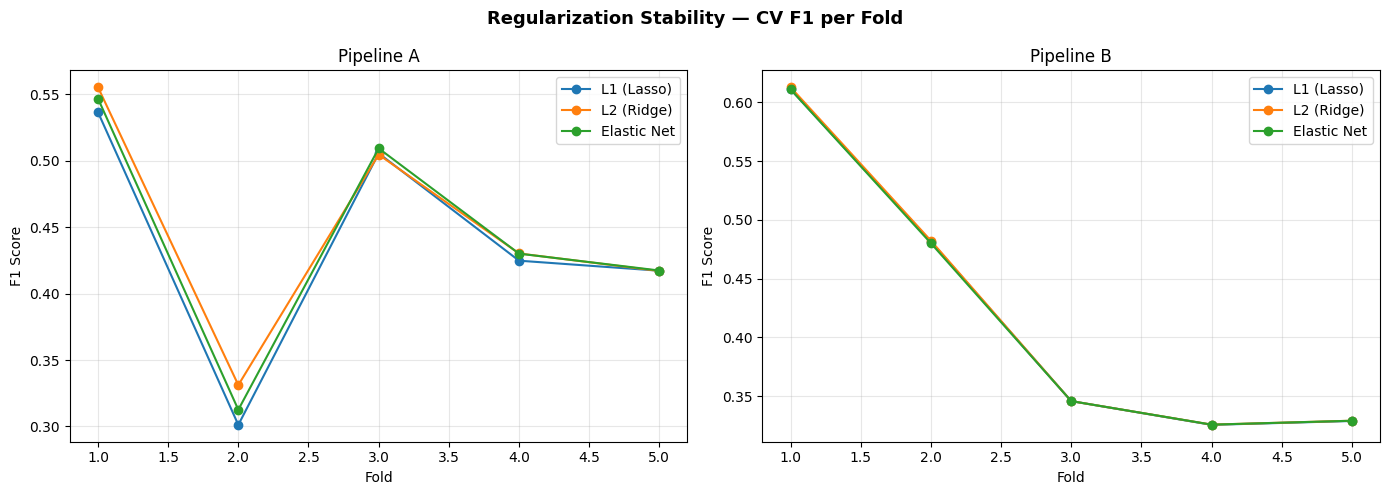

In [16]:
# ── Plot 1: CV Stability (F1 per fold) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regularization Stability — CV F1 per Fold', fontsize=13, fontweight='bold')

for ax, results, title in zip(axes,
                               [results_A, results_B],
                               ['Pipeline A', 'Pipeline B']):
    for name, res in results.items():
        ax.plot(range(1, 6), res['cv_scores'], marker='o', label=name)
    ax.set_title(title)
    ax.set_xlabel('Fold')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regularization_stability.png', dpi=150, bbox_inches='tight')
plt.show()

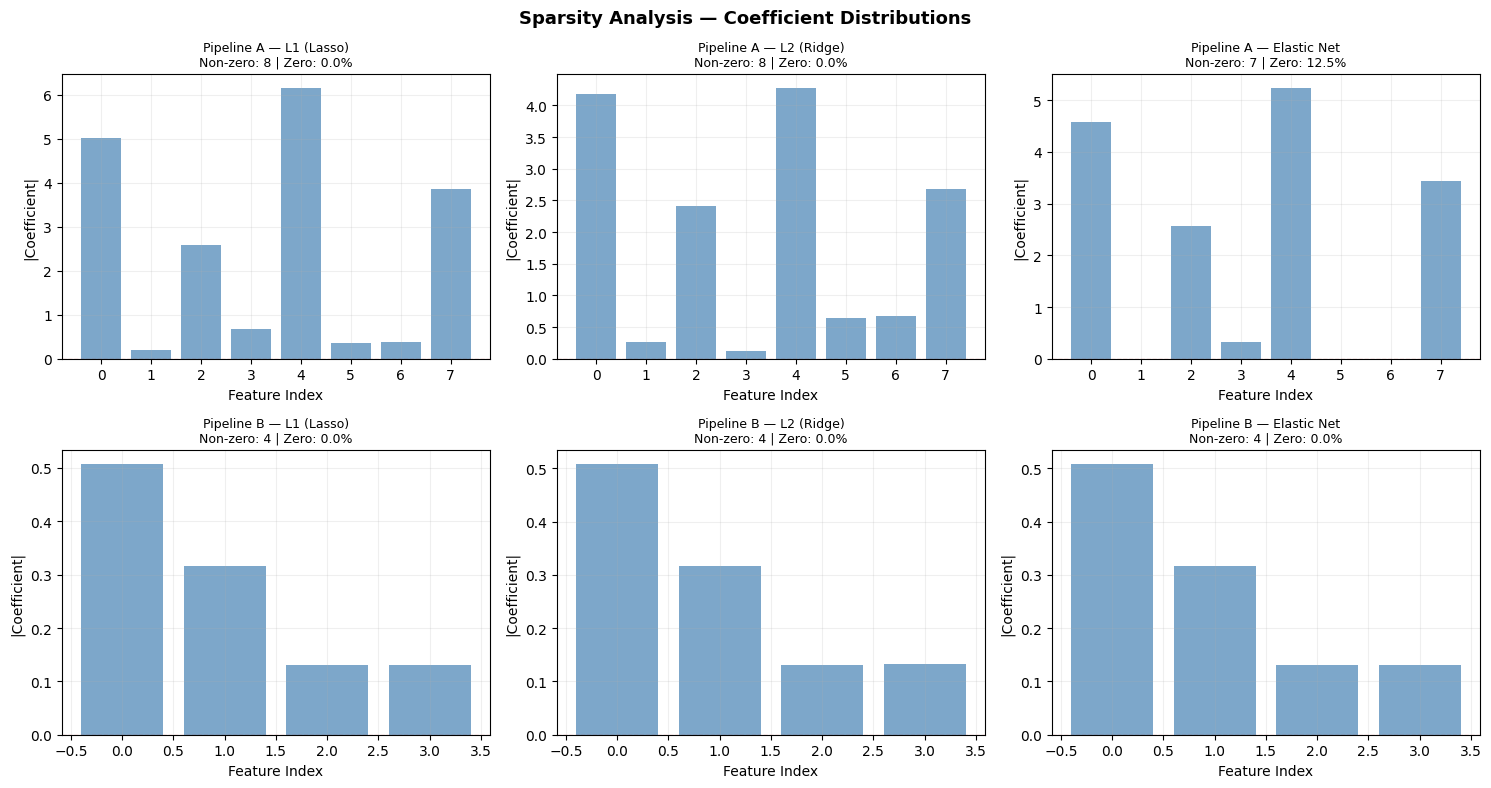

In [17]:
# ── Plot 2: Sparsity — Coefficient Distributions ──────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sparsity Analysis — Coefficient Distributions', fontsize=13, fontweight='bold')

for col, (name, _) in enumerate(models.items()):
    for row, (results, pip_name) in enumerate([(results_A, 'Pipeline A'),
                                                (results_B, 'Pipeline B')]):
        ax   = axes[row][col]
        coef = results[name]['coef']
        ax.bar(range(len(coef)), np.abs(coef), color='steelblue', alpha=0.7)
        ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
        ax.set_title(f'{pip_name} — {name}\n'
                     f'Non-zero: {results[name]["n_nonzero"]} | '
                     f'Zero: {results[name]["zero_pct"]:.1f}%', fontsize=9)
        ax.set_xlabel('Feature Index')
        ax.set_ylabel('|Coefficient|')
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('sparsity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Summary Comparison Table ─────────────────────────────────────────

summary = []
for name in models:
    summary.append({
        'Model'          : name,
        'Pipeline A F1'  : f"{results_A[name]['cv_mean']:.4f} ± {results_A[name]['cv_std']:.4f}",
        'Pipeline B F1'  : f"{results_B[name]['cv_mean']:.4f} ± {results_B[name]['cv_std']:.4f}",
        'A Zero Coef %'  : f"{results_A[name]['zero_pct']:.1f}%",
        'B Zero Coef %'  : f"{results_B[name]['zero_pct']:.1f}%",
    })

print("\n=== Summary Table ===")
print(pd.DataFrame(summary).to_string(index=False))


=== Summary Table ===
      Model   Pipeline A F1   Pipeline B F1 A Zero Coef % B Zero Coef %
 L1 (Lasso) 0.4371 ± 0.0820 0.4186 ± 0.1123          0.0%          0.0%
 L2 (Ridge) 0.4477 ± 0.0770 0.4192 ± 0.1129          0.0%          0.0%
Elastic Net 0.4432 ± 0.0813 0.4184 ± 0.1121         12.5%          0.0%


### Handling Class Imbalance

In [19]:
# ── Train/Test Split (Pipeline A — best performing) ───────────────────────────

X_tr, X_te, y_tr, y_te = train_test_split(
    X_A, y, test_size=0.2, random_state=42, stratify=y
)

print("Original class distribution:")
print(pd.Series(y_tr).value_counts())

# ── Apply Techniques ──────────────────────────────────────────────────────────

# 1. SMOTE
sm              = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X_tr, y_tr)

# 2. Undersampling
rus                 = RandomUnderSampler(random_state=42)
X_under, y_under   = rus.fit_resample(X_tr, y_tr)

# 3. Class Weighting (no resampling, handled in model)
# Done via class_weight='balanced' in LR

print(f"\nAfter SMOTE       : {pd.Series(y_smote).value_counts().to_dict()}")
print(f"After Undersampling: {pd.Series(y_under).value_counts().to_dict()}")

# ── Train & Evaluate All Variants ─────────────────────────────────────────────

variants = {
    'No Handling'    : (X_tr,     y_tr,     LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    'SMOTE'          : (X_smote,  y_smote,  LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    'Undersampling'  : (X_under,  y_under,  LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    'Class Weighting': (X_tr,     y_tr,     LogisticRegression(C=1.0, max_iter=1000, random_state=42,
                                                                 class_weight='balanced')),
}

results = {}
for name, (X_train, y_train, model) in variants.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    from sklearn.metrics import precision_score, recall_score, f1_score
    results[name] = {
        'precision' : precision_score(y_te, y_pred,  zero_division=0),
        'recall'    : recall_score(y_te, y_pred,     zero_division=0),
        'f1'        : f1_score(y_te, y_pred,         zero_division=0),
        'pr_auc'    : average_precision_score(y_te, y_proba),
        'proba'     : y_proba,
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_te, y_pred,
                                 target_names=['Non-Seizure', 'Seizure'],
                                 zero_division=0))


Original class distribution:
y
0    4800
1    1600
Name: count, dtype: int64

After SMOTE       : {0: 4800, 1: 4800}
After Undersampling: {0: 1600, 1: 1600}

=== No Handling ===
              precision    recall  f1-score   support

 Non-Seizure       0.75      0.99      0.85      1200
     Seizure       0.35      0.02      0.04       400

    accuracy                           0.75      1600
   macro avg       0.55      0.50      0.45      1600
weighted avg       0.65      0.75      0.65      1600


=== SMOTE ===
              precision    recall  f1-score   support

 Non-Seizure       0.82      0.63      0.71      1200
     Seizure       0.35      0.59      0.44       400

    accuracy                           0.62      1600
   macro avg       0.58      0.61      0.57      1600
weighted avg       0.70      0.62      0.64      1600


=== Undersampling ===
              precision    recall  f1-score   support

 Non-Seizure       0.83      0.63      0.71      1200
     Seizure       0.

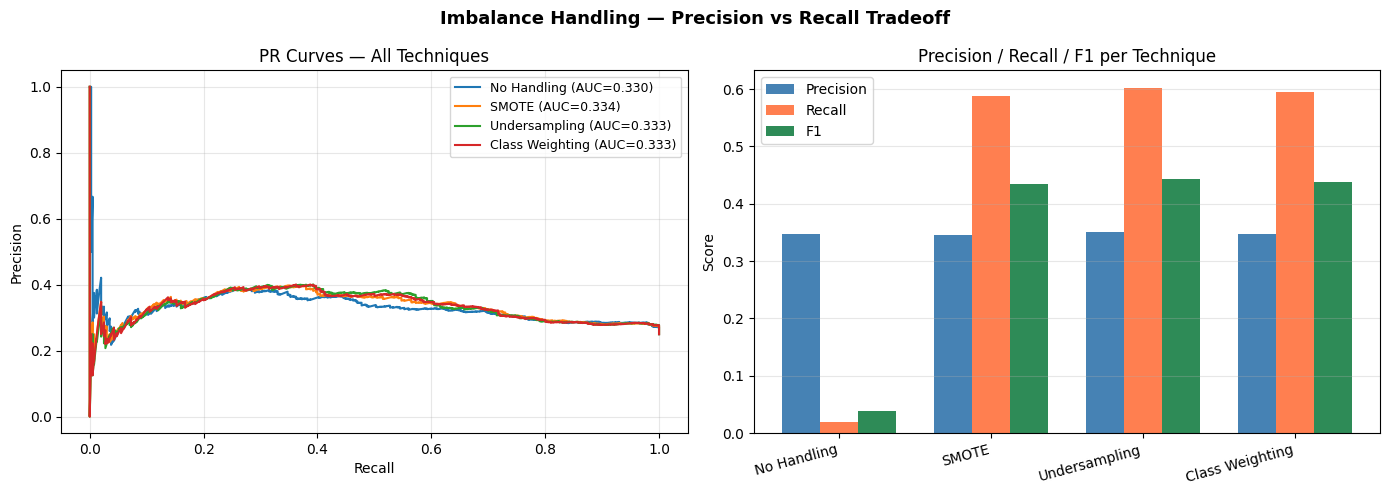

In [20]:

# ── Plot 1: Precision vs Recall Tradeoff (PR Curves) ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Imbalance Handling — Precision vs Recall Tradeoff', fontsize=13, fontweight='bold')

# PR Curves
ax = axes[0]
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_te, res['proba'])
    ax.plot(rec, prec, label=f"{name} (AUC={res['pr_auc']:.3f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curves — All Techniques')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Bar: Precision vs Recall per technique
ax  = axes[1]
names = list(results.keys())
prec  = [results[n]['precision'] for n in names]
rec   = [results[n]['recall']    for n in names]
f1    = [results[n]['f1']        for n in names]
x     = np.arange(len(names))
w     = 0.25

ax.bar(x - w,  prec, w, label='Precision', color='steelblue')
ax.bar(x,      rec,  w, label='Recall',    color='coral')
ax.bar(x + w,  f1,   w, label='F1',        color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 per Technique')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('imbalance_handling.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:

# ── Summary Table ─────────────────────────────────────────────────────────────

summary = pd.DataFrame([{
    'Technique' : n,
    'Precision' : f"{r['precision']:.4f}",
    'Recall'    : f"{r['recall']:.4f}",
    'F1'        : f"{r['f1']:.4f}",
    'PR-AUC'    : f"{r['pr_auc']:.4f}",
} for n, r in results.items()])

print("\n=== Summary Table ===")
print(summary.to_string(index=False))


=== Summary Table ===
      Technique Precision Recall     F1 PR-AUC
    No Handling    0.3478 0.0200 0.0378 0.3299
          SMOTE    0.3456 0.5875 0.4352 0.3340
  Undersampling    0.3503 0.6025 0.4430 0.3334
Class Weighting    0.3474 0.5950 0.4387 0.3333


In [22]:
# ============================================================
# HELPER: extract mean abs + std of EEG time-series windows
# Used in Pipeline B for dataset3 (Bonn) which has 4097 raw signal features
# ============================================================
def extract_time_series_features(X):
    """
    Extract statistical features from raw EEG time-series.
    Works for any array of shape (n_samples, n_timepoints).
    Returns (n_samples, 6) feature matrix.
    """
    return np.column_stack([
        np.mean(X, axis=1),
        np.std(X, axis=1),
        np.max(X, axis=1) - np.min(X, axis=1),   # peak-to-peak amplitude
        np.percentile(X, 75, axis=1) - np.percentile(X, 25, axis=1),  # IQR
        np.mean(np.abs(np.diff(X, axis=1)), axis=1),  # mean abs diff (activity)
        np.sum(X ** 2, axis=1) / X.shape[1],       # mean energy
    ])

In [23]:
# ============================================================
# HELPER: unified evaluation
# ============================================================
def evaluate(model, X_tr, y_tr, X_te, y_te, label=""):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if len(np.unique(y_te)) == 2 else None
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='binary' if len(np.unique(y_te)) == 2 else 'macro')
    prauc = average_precision_score(y_te, y_prob) if y_prob is not None else None
    if label:
        prauc_str = f"{prauc:.4f}" if prauc is not None else "N/A (multiclass)"
        print(f"  {label:<25} Acc: {acc:.4f} | F1: {f1:.4f} | PR-AUC: {prauc_str}")
    return acc, f1, prauc

###############################################################################

## 2. MIT Data

###############################################################################

In [24]:
# ============================================================
# SECTION A: MIT_data  (Epileptic Seizure Recognition, Kaggle)
# 11500 rows, 178 EEG time-series features, 5 classes (1–5)
# Binary target: y==1 → seizure (1), else → non-seizure (0)
# ============================================================

print("\n" + "="*70)
print("DATASET 2: MIT_data (Epileptic Seizure Recognition)")
print("="*70)

# ── Load ──────────────────────────────────────────────────────────────────────
MIT_data = pd.read_csv("/content/drive/MyDrive/AI_work/ims/Data Mining/Major Project/data/Epileptic Seizure Recognition.csv")

# Drop the non-numeric ID column
MIT_data = MIT_data.drop(columns=['Unnamed'], errors='ignore')

# Binary label: seizure (class 1) vs. all others
X_mit = MIT_data.drop(columns=['y']).values
y_mit = (MIT_data['y'] == 1).astype(int).values  # 1 = seizure, 0 = non-seizure

print(f"Shape: {X_mit.shape}  |  Seizure: {y_mit.sum()} ({y_mit.mean()*100:.1f}%)")

X_tr_mit, X_te_mit, y_tr_mit, y_te_mit = train_test_split(
    X_mit, y_mit, test_size=0.2, random_state=42, stratify=y_mit)


DATASET 2: MIT_data (Epileptic Seizure Recognition)
Shape: (11500, 178)  |  Seizure: 2300 (20.0%)


In [25]:
# Checking null values
MIT_data.isnull().sum().sum()

np.int64(0)

### PIPELINE A

In [26]:
# ── Pipeline A: Normalization → Noise Removal (clip outliers) → SelectKBest ──
print("\n--- MIT | Pipeline A: Normalize → Clip Outliers → SelectKBest ---")

# Step 1: Normalize (RobustScaler handles EEG outliers better than MinMax)
scaler_A_mit = RobustScaler()
X_tr_A_mit = scaler_A_mit.fit_transform(X_tr_mit)
X_te_A_mit  = scaler_A_mit.transform(X_te_mit)

# Step 2: Noise removal — clip extreme values beyond ±3σ
clip_val = 3.0
X_tr_A_mit = np.clip(X_tr_A_mit, -clip_val, clip_val)
X_te_A_mit  = np.clip(X_te_A_mit,  -clip_val, clip_val)

# Step 3: Feature selection — top 50 features (out of 178)
selector_mit = SelectKBest(f_classif, k=50)
X_tr_A_mit = selector_mit.fit_transform(X_tr_A_mit, y_tr_mit)
X_te_A_mit  = selector_mit.transform(X_te_A_mit)

print(f"  Pipeline A shape: {X_tr_A_mit.shape}")


--- MIT | Pipeline A: Normalize → Clip Outliers → SelectKBest ---
  Pipeline A shape: (9200, 50)


### PIPELINE B

In [27]:
# ── Pipeline B: Feature Extraction → StandardScaler → PCA ────────────────────
print("\n--- MIT | Pipeline B: Extract Features → Scale → PCA ---")

# Step 1: Extract statistical features from 178 time-series points
X_tr_B_mit = extract_time_series_features(X_tr_mit)
X_te_B_mit  = extract_time_series_features(X_te_mit)

# Step 2: Scale
scaler_B_mit = StandardScaler()
X_tr_B_mit = scaler_B_mit.fit_transform(X_tr_B_mit)
X_te_B_mit  = scaler_B_mit.transform(X_te_B_mit)

# Step 3: PCA — keep 95% variance (6 features → all components, but structure preserved)
pca_mit = PCA(n_components=0.95, random_state=42)
X_tr_B_mit = pca_mit.fit_transform(X_tr_B_mit)
X_te_B_mit  = pca_mit.transform(X_te_B_mit)

print(f"  Pipeline B shape: {X_tr_B_mit.shape}")


--- MIT | Pipeline B: Extract Features → Scale → PCA ---
  Pipeline B shape: (9200, 2)


### Logistic Regression

In [28]:
# ── 3. Baseline Logistic Regression ──────────────────────────────────────────
print("\n--- MIT | Baseline Logistic Regression ---")
base_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
evaluate(base_lr, X_tr_A_mit, y_tr_mit, X_te_A_mit, y_te_mit, "Pipeline A (baseline)")
evaluate(base_lr, X_tr_B_mit, y_tr_mit, X_te_B_mit, y_te_mit, "Pipeline B (baseline)")



--- MIT | Baseline Logistic Regression ---
  Pipeline A (baseline)     Acc: 0.5683 | F1: 0.2942 | PR-AUC: 0.3753
  Pipeline B (baseline)     Acc: 0.9517 | F1: 0.8857 | PR-AUC: 0.9550


(0.9517391304347826, 0.8856848609680742, np.float64(0.9550117750009508))

### Demonstrating Overfitting & Underfitting


--- MIT | Overfit / Underfit Demo ---


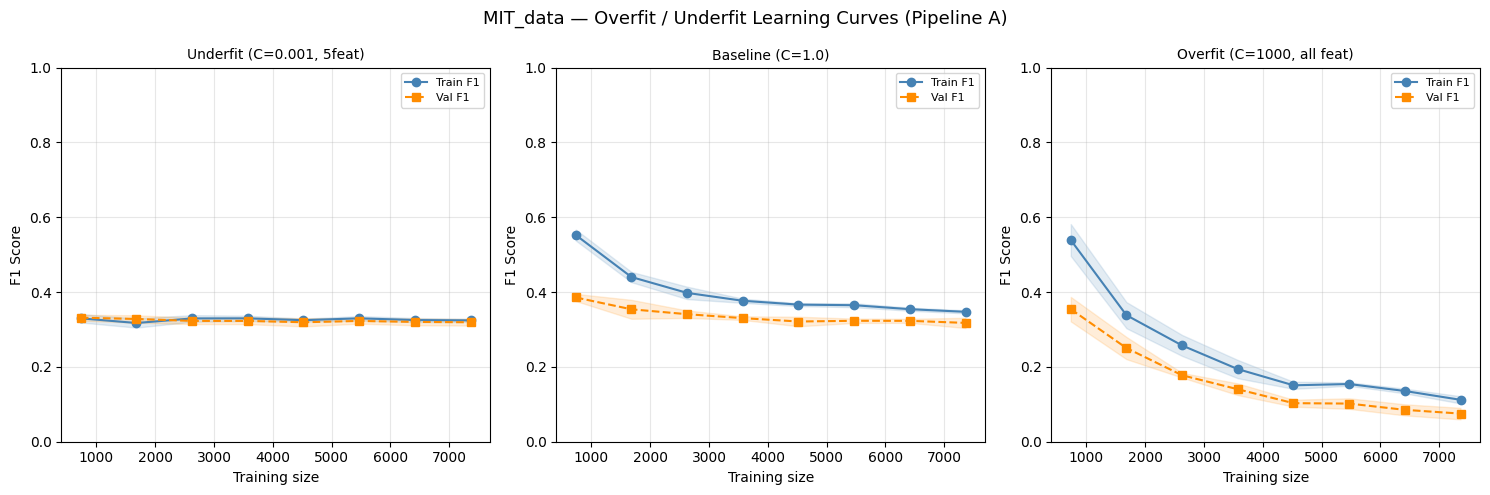

In [29]:
# ── 4. Overfitting & Underfitting of Pipeline A ─────────────────────────────
print("\n--- MIT | Overfit / Underfit Demo ---")
from sklearn.metrics import make_scorer, f1_score
f1_scorer = make_scorer(f1_score, zero_division=0)

scenarios = {
    "Underfit (C=0.001, 5feat)": {
        "model": LogisticRegression(
            C=0.001, max_iter=1000, random_state=42,
            class_weight='balanced'
        ),
        "use_select": True, "k": 5
    },
    "Baseline (C=1.0)": {
        "model": LogisticRegression(
            C=1.0, max_iter=1000, random_state=42,
            class_weight='balanced'
        ),
        "use_select": False, "k": None
    },
    "Overfit (C=1000, all feat)": {
        "model": LogisticRegression(
            C=1000, max_iter=2000, random_state=42
        ),
        "use_select": False, "k": None
    },
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("MIT_data — Overfit / Underfit Learning Curves (Pipeline A)", fontsize=13)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ax, (name, cfg) in zip(axes, scenarios.items()):
    if cfg["use_select"]:
        sel = SelectKBest(f_classif, k=cfg["k"])
        Xtr = sel.fit_transform(X_tr_A_mit, y_tr_mit)
        Xte = sel.transform(X_te_A_mit)
    else:
        Xtr, Xte = X_tr_A_mit, X_te_A_mit

    sizes, tr_scores, val_scores = learning_curve(
        cfg["model"], Xtr, y_tr_mit,
        cv=skf,
        scoring=f1_scorer,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    tr_mean  = np.clip(tr_scores.mean(axis=1),  0, 1)
    tr_std   = tr_scores.std(axis=1)
    val_mean = np.clip(val_scores.mean(axis=1), 0, 1)
    val_std  = val_scores.std(axis=1)

    ax.plot(sizes, tr_mean,  'o-',  label='Train F1', color='steelblue')
    ax.plot(sizes, val_mean, 's--', label='Val F1',   color='darkorange')
    ax.fill_between(sizes,
                    np.clip(tr_mean - tr_std,  0, 1),
                    np.clip(tr_mean + tr_std,  0, 1),
                    alpha=0.15, color='steelblue')
    ax.fill_between(sizes,
                    np.clip(val_mean - val_std, 0, 1),
                    np.clip(val_mean + val_std, 0, 1),
                    alpha=0.15, color='darkorange')

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Training size")
    ax.set_ylabel("F1 Score")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overfit_underfit_MIT_A.png', dpi=150, bbox_inches='tight')
plt.show()

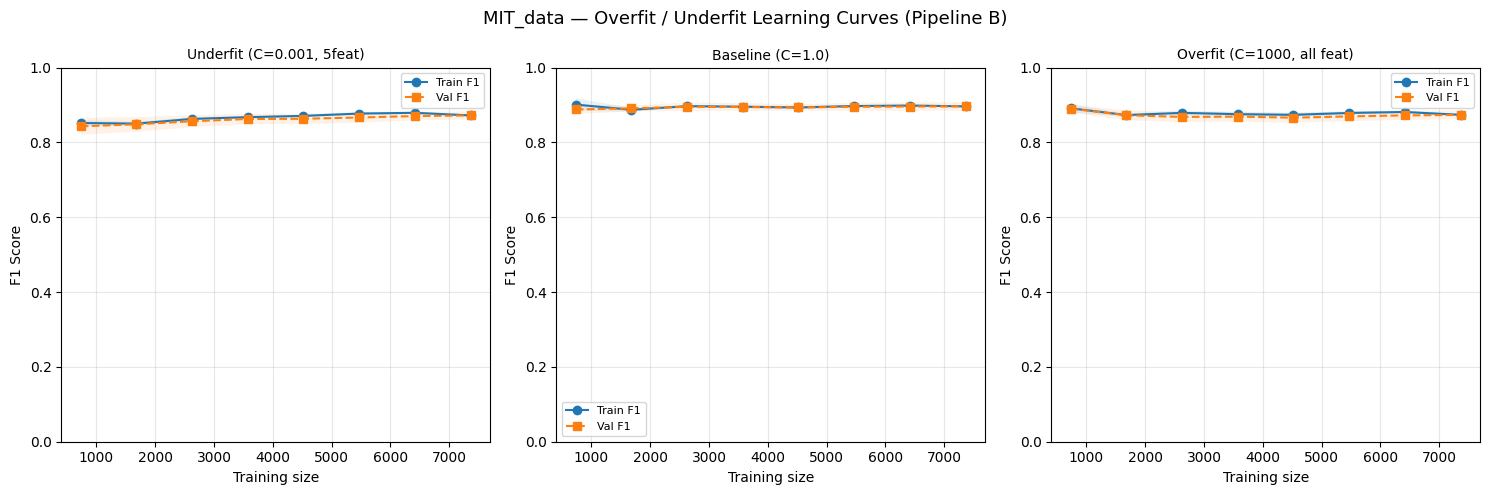

In [30]:
# Pipeline B overfit/underfit
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("MIT_data — Overfit / Underfit Learning Curves (Pipeline B)", fontsize=13)

for ax, (name, cfg) in zip(axes, scenarios.items()):
    sizes, tr_scores, val_scores = learning_curve(
        cfg["model"], X_tr_B_mit, y_tr_mit,
        cv=skf, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    ax.plot(sizes, tr_scores.mean(axis=1), 'o-', label='Train F1')
    ax.plot(sizes, val_scores.mean(axis=1), 's--', label='Val F1')
    ax.fill_between(sizes, tr_scores.mean(axis=1)-tr_scores.std(axis=1),
                    tr_scores.mean(axis=1)+tr_scores.std(axis=1), alpha=0.1)
    ax.fill_between(sizes, val_scores.mean(axis=1)-val_scores.std(axis=1),
                    val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Training size")
    ax.set_ylabel("F1 Score")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overfit_underfit_MIT_B.png', dpi=150, bbox_inches='tight')
plt.show()

### Regularization Study


In [31]:
# ── 5. Regularization Study ───────────────────────────────────────────────────
print("\n--- MIT | Regularization Study (L1 / L2 / ElasticNet) ---")

reg_models = {
    "L1 (Lasso)"    : LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=2000, random_state=42, class_weight='balanced'),
    "L2 (Ridge)"    : LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42, class_weight='balanced'),
    "ElasticNet"    : LogisticRegression(penalty='elasticnet', C=1.0, solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42, class_weight='balanced'),
}

results_A_mit, results_B_mit = {}, {}

for name, model in reg_models.items():
    cv_A = cross_val_score(model, X_tr_A_mit, y_tr_mit, cv=skf, scoring='f1', n_jobs=-1)
    cv_B = cross_val_score(model, X_tr_B_mit, y_tr_mit, cv=skf, scoring='f1', n_jobs=-1)
    model.fit(X_tr_A_mit, y_tr_mit)
    coef_A = model.coef_.ravel()
    model.fit(X_tr_B_mit, y_tr_mit)
    coef_B = model.coef_.ravel()
    results_A_mit[name] = {"cv_mean": cv_A.mean(), "cv_std": cv_A.std(),
                            "n_nonzero": np.sum(coef_A != 0), "zero_pct": np.mean(coef_A == 0)*100}
    results_B_mit[name] = {"cv_mean": cv_B.mean(), "cv_std": cv_B.std(),
                            "n_nonzero": np.sum(coef_B != 0), "zero_pct": np.mean(coef_B == 0)*100}
    print(f"  {name:<15}  "
          f"Pipe-A: {cv_A.mean():.4f}±{cv_A.std():.4f}  "
          f"Pipe-B: {cv_B.mean():.4f}±{cv_B.std():.4f}")




--- MIT | Regularization Study (L1 / L2 / ElasticNet) ---
  L1 (Lasso)       Pipe-A: 0.3149±0.0128  Pipe-B: 0.8960±0.0112
  L2 (Ridge)       Pipe-A: 0.3176±0.0137  Pipe-B: 0.8964±0.0116
  ElasticNet       Pipe-A: 0.3167±0.0130  Pipe-B: 0.8962±0.0109


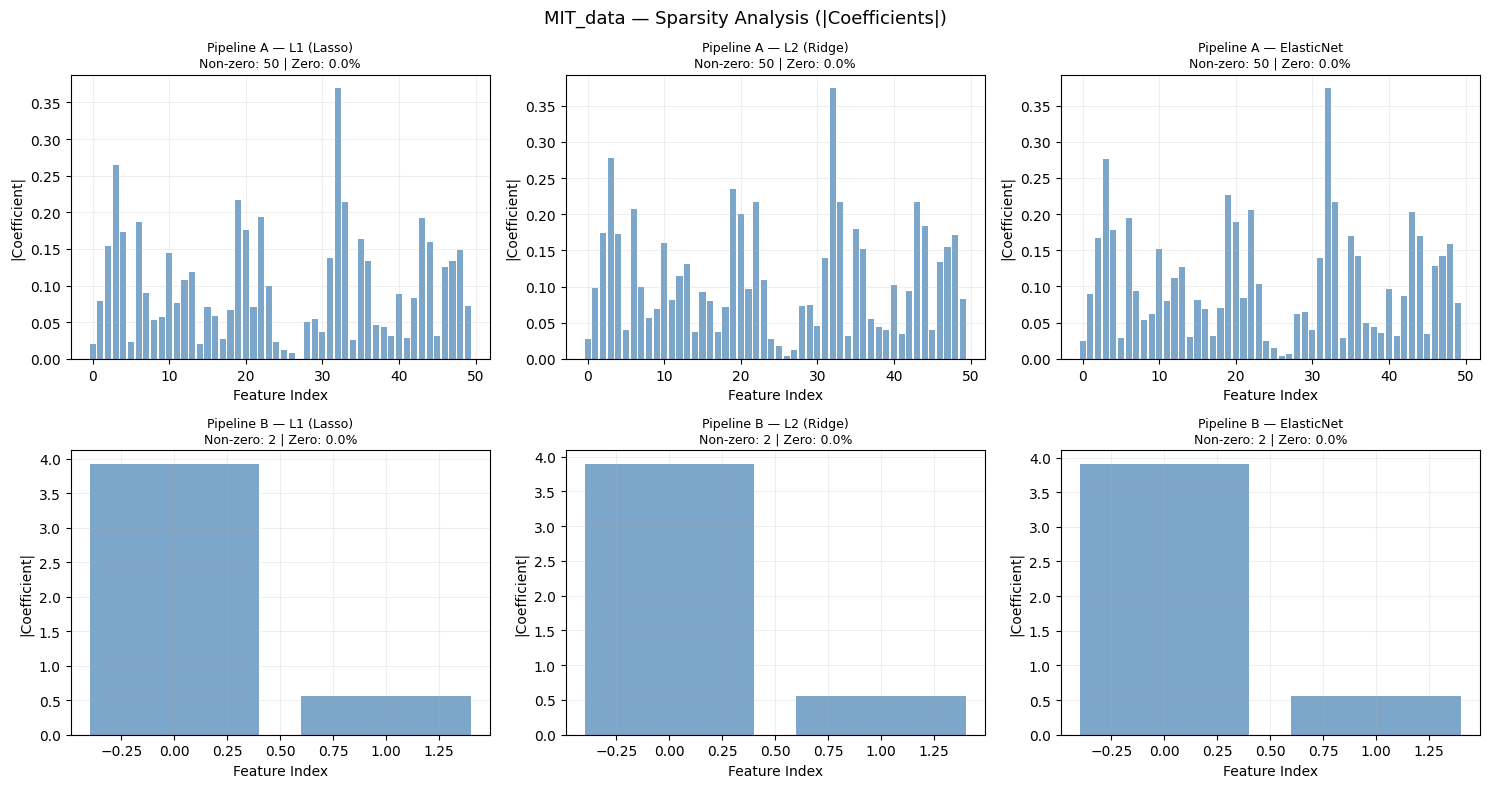


=== MIT Regularization Summary ===
     Model   Pipeline A F1   Pipeline B F1 A Zero Coef % B Zero Coef %
L1 (Lasso) 0.3149 ± 0.0128 0.8960 ± 0.0112          0.0%          0.0%
L2 (Ridge) 0.3176 ± 0.0137 0.8964 ± 0.0116          0.0%          0.0%
ElasticNet 0.3167 ± 0.0130 0.8962 ± 0.0109          0.0%          0.0%


In [32]:
# Sparsity plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("MIT_data — Sparsity Analysis (|Coefficients|)", fontsize=13)
for col, (name, model) in enumerate(reg_models.items()):
    for row, (pip_name, Xtr, res) in enumerate([("Pipeline A", X_tr_A_mit, results_A_mit),
                                                 ("Pipeline B", X_tr_B_mit, results_B_mit)]):
        model.fit(Xtr, y_tr_mit)
        coef = np.abs(model.coef_.ravel())
        ax = axes[row][col]
        ax.bar(range(len(coef)), coef, color='steelblue', alpha=0.7)
        ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
        ax.set_title(f"{pip_name} — {name}\nNon-zero: {res[name]['n_nonzero']} | "
                     f"Zero: {res[name]['zero_pct']:.1f}%", fontsize=9)
        ax.set_xlabel("Feature Index")
        ax.set_ylabel("|Coefficient|")
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('sparsity_MIT.png', dpi=150, bbox_inches='tight')
plt.show()

summary_mit = []
for name in reg_models:
    summary_mit.append({
        'Model'         : name,
        'Pipeline A F1' : f"{results_A_mit[name]['cv_mean']:.4f} ± {results_A_mit[name]['cv_std']:.4f}",
        'Pipeline B F1' : f"{results_B_mit[name]['cv_mean']:.4f} ± {results_B_mit[name]['cv_std']:.4f}",
        'A Zero Coef %' : f"{results_A_mit[name]['zero_pct']:.1f}%",
        'B Zero Coef %' : f"{results_B_mit[name]['zero_pct']:.1f}%",
    })
print("\n=== MIT Regularization Summary ===")
print(pd.DataFrame(summary_mit).to_string(index=False))

### Handling Imbalance

In [33]:
# ── 6. Class Imbalance Handling ───────────────────────────────────────────────
print("\n--- MIT | Class Imbalance Handling ---")

imbalance_results_mit = {}
base_model_mit = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

for pip_name, Xtr, Xte in [("Pipeline A", X_tr_A_mit, X_te_A_mit),
                             ("Pipeline B", X_tr_B_mit, X_te_B_mit)]:
    print(f"\n=== {pip_name} ===")
    imbalance_results_mit[pip_name] = {}

    # No handling
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    m.fit(Xtr, y_tr_mit)
    yp = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:, 1]
    p, r, f, prauc = (precision_score(y_te_mit, yp), recall_score(y_te_mit, yp),
                      f1_score(y_te_mit, yp), average_precision_score(y_te_mit, yprob))
    imbalance_results_mit[pip_name]["No Handling"] = (p, r, f, prauc)
    print(f"  {'No Handling':<20} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f:.4f} | PR-AUC: {prauc:.4f}")

    # SMOTE
    sm = SMOTE(random_state=42)
    Xtr_sm, ytr_sm = sm.fit_resample(Xtr, y_tr_mit)
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    m.fit(Xtr_sm, ytr_sm)
    yp = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:, 1]
    p, r, f, prauc = (precision_score(y_te_mit, yp), recall_score(y_te_mit, yp),
                      f1_score(y_te_mit, yp), average_precision_score(y_te_mit, yprob))
    imbalance_results_mit[pip_name]["SMOTE"] = (p, r, f, prauc)
    print(f"  {'SMOTE':<20} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f:.4f} | PR-AUC: {prauc:.4f}")

    # Undersampling
    rus = RandomUnderSampler(random_state=42)
    Xtr_us, ytr_us = rus.fit_resample(Xtr, y_tr_mit)
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    m.fit(Xtr_us, ytr_us)
    yp = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:, 1]
    p, r, f, prauc = (precision_score(y_te_mit, yp), recall_score(y_te_mit, yp),
                      f1_score(y_te_mit, yp), average_precision_score(y_te_mit, yprob))
    imbalance_results_mit[pip_name]["Undersampling"] = (p, r, f, prauc)
    print(f"  {'Undersampling':<20} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f:.4f} | PR-AUC: {prauc:.4f}")

    # Class weighting
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
    m.fit(Xtr, y_tr_mit)
    yp = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:, 1]
    p, r, f, prauc = (precision_score(y_te_mit, yp), recall_score(y_te_mit, yp),
                      f1_score(y_te_mit, yp), average_precision_score(y_te_mit, yprob))
    imbalance_results_mit[pip_name]["Class Weighting"] = (p, r, f, prauc)
    print(f"  {'Class Weighting':<20} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f:.4f} | PR-AUC: {prauc:.4f}")




--- MIT | Class Imbalance Handling ---

=== Pipeline A ===
  No Handling          | Precision: 1.0000 | Recall: 0.0413 | F1: 0.0793 | PR-AUC: 0.3871
  SMOTE                | Precision: 0.2320 | Recall: 0.4630 | F1: 0.3091 | PR-AUC: 0.3901
  Undersampling        | Precision: 0.2202 | Recall: 0.4696 | F1: 0.2998 | PR-AUC: 0.3716
  Class Weighting      | Precision: 0.2186 | Recall: 0.4500 | F1: 0.2942 | PR-AUC: 0.3753

=== Pipeline B ===
  No Handling          | Precision: 0.9280 | Recall: 0.8130 | F1: 0.8667 | PR-AUC: 0.9548
  SMOTE                | Precision: 0.8439 | Recall: 0.9283 | F1: 0.8841 | PR-AUC: 0.9551
  Undersampling        | Precision: 0.8366 | Recall: 0.9348 | F1: 0.8830 | PR-AUC: 0.9551
  Class Weighting      | Precision: 0.8415 | Recall: 0.9348 | F1: 0.8857 | PR-AUC: 0.9550


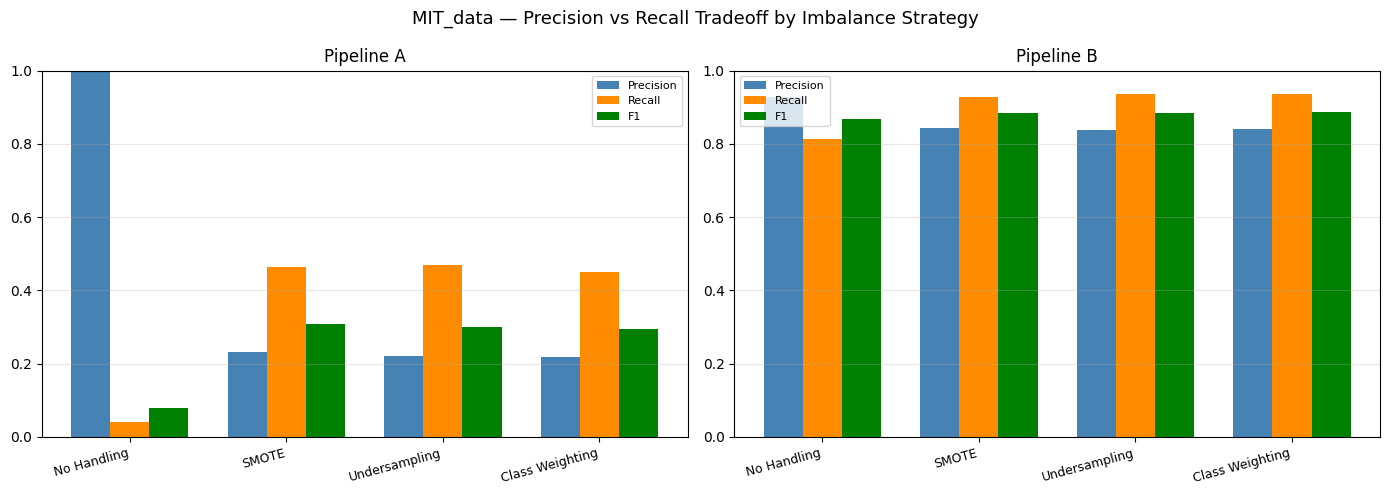

In [34]:
# Plot precision-recall tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MIT_data — Precision vs Recall Tradeoff by Imbalance Strategy", fontsize=13)
colors = ['gray', 'steelblue', 'darkorange', 'green']
methods = ["No Handling", "SMOTE", "Undersampling", "Class Weighting"]

for ax, (pip_name, res) in zip(axes, imbalance_results_mit.items()):
    precisions = [res[m][0] for m in methods]
    recalls    = [res[m][1] for m in methods]
    f1s        = [res[m][2] for m in methods]
    x = np.arange(len(methods))
    w = 0.25
    ax.bar(x - w, precisions, w, label='Precision', color='steelblue')
    ax.bar(x,     recalls,    w, label='Recall',    color='darkorange')
    ax.bar(x + w, f1s,        w, label='F1',        color='green')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=9)
    ax.set_title(pip_name)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('imbalance_MIT.png', dpi=150, bbox_inches='tight')
plt.show()


###############################################################################

## 3. Kaggle Bonn University Data

###############################################################################

In [47]:
# ============================================================
# SECTION B: dataset3 (Bonn University EEG)
# 400 samples, 4097 raw EEG signal features, 5 classes (F,N,O,S,Z)
# Binary target: S = seizure (1), rest = non-seizure (0)
# ============================================================

print("\n" + "="*70)
print("DATASET 3: Bonn University EEG Dataset")
print("="*70)

# ── Load ──────────────────────────────────────────────────────────────────────
bonn = pd.read_csv("/content/drive/MyDrive/AI_work/ims/Data Mining/Major Project/data/bonn_eeg.csv")

X_bonn = bonn.drop(columns=['label']).values.astype(float)
y_bonn = (bonn['label'] == 'S').astype(int).values  # S = ictal (seizure)

print(f"Shape: {X_bonn.shape}  |  Seizure: {y_bonn.sum()} ({y_bonn.mean()*100:.1f}%)")

X_tr_bonn, X_te_bonn, y_tr_bonn, y_te_bonn = train_test_split(
    X_bonn, y_bonn, test_size=0.2, random_state=42, stratify=y_bonn)


DATASET 3: Bonn University EEG Dataset
Shape: (400, 4097)  |  Seizure: 100 (25.0%)


In [48]:
# Checking null values
bonn.isnull().sum().sum()

np.int64(0)

### Pipeline A

In [49]:

# ── Pipeline A: Normalize → Clip Outliers → SelectKBest ─────────────────────
print("\n--- Bonn | Pipeline A: RobustScale → Clip → SelectKBest(k=30) ---")

scaler_A_bonn = RobustScaler()
X_tr_A_bonn = scaler_A_bonn.fit_transform(X_tr_bonn)
X_te_A_bonn  = scaler_A_bonn.transform(X_te_bonn)

X_tr_A_bonn = np.clip(X_tr_A_bonn, -3, 3)
X_te_A_bonn  = np.clip(X_te_A_bonn,  -3, 3)

# k=30 because we have only 320 training samples — avoid curse of dimensionality
selector_bonn = SelectKBest(f_classif, k=30)
X_tr_A_bonn = selector_bonn.fit_transform(X_tr_A_bonn, y_tr_bonn)
X_te_A_bonn  = selector_bonn.transform(X_te_A_bonn)

print(f"  Pipeline A shape: {X_tr_A_bonn.shape}")


--- Bonn | Pipeline A: RobustScale → Clip → SelectKBest(k=30) ---
  Pipeline A shape: (320, 30)


### Pipeline B

In [50]:
# ── Pipeline B: Extract Statistical Features → StandardScaler → PCA ──────────
print("\n--- Bonn | Pipeline B: Extract Features → Scale → PCA ---")

X_tr_B_bonn = extract_time_series_features(X_tr_bonn)
X_te_B_bonn  = extract_time_series_features(X_te_bonn)

scaler_B_bonn = StandardScaler()
X_tr_B_bonn = scaler_B_bonn.fit_transform(X_tr_B_bonn)
X_te_B_bonn  = scaler_B_bonn.transform(X_te_B_bonn)

pca_bonn = PCA(n_components=0.95, random_state=42)
X_tr_B_bonn = pca_bonn.fit_transform(X_tr_B_bonn)
X_te_B_bonn  = pca_bonn.transform(X_te_B_bonn)

print(f"  Pipeline B shape: {X_tr_B_bonn.shape}")


--- Bonn | Pipeline B: Extract Features → Scale → PCA ---
  Pipeline B shape: (320, 2)


### Applying Logistic Regression

In [51]:
# ── 3. Baseline Logistic Regression ──────────────────────────────────────────
print("\n--- Bonn | Baseline Logistic Regression ---")
base_lr_bonn = LogisticRegression(C=1.0, max_iter=1000, random_state=42 , class_weight='balanced')
evaluate(base_lr_bonn, X_tr_A_bonn, y_tr_bonn, X_te_A_bonn, y_te_bonn, "Pipeline A (baseline)")
evaluate(base_lr_bonn, X_tr_B_bonn, y_tr_bonn, X_te_B_bonn, y_te_bonn, "Pipeline B (baseline)")


--- Bonn | Baseline Logistic Regression ---
  Pipeline A (baseline)     Acc: 0.7875 | F1: 0.5143 | PR-AUC: 0.5941
  Pipeline B (baseline)     Acc: 0.9250 | F1: 0.8571 | PR-AUC: 0.9070


(0.925, 0.8571428571428571, np.float64(0.9069536174180137))

### Demonstrating Overfitting and Underfitting


--- Bonn | Overfit / Underfit Demo ---


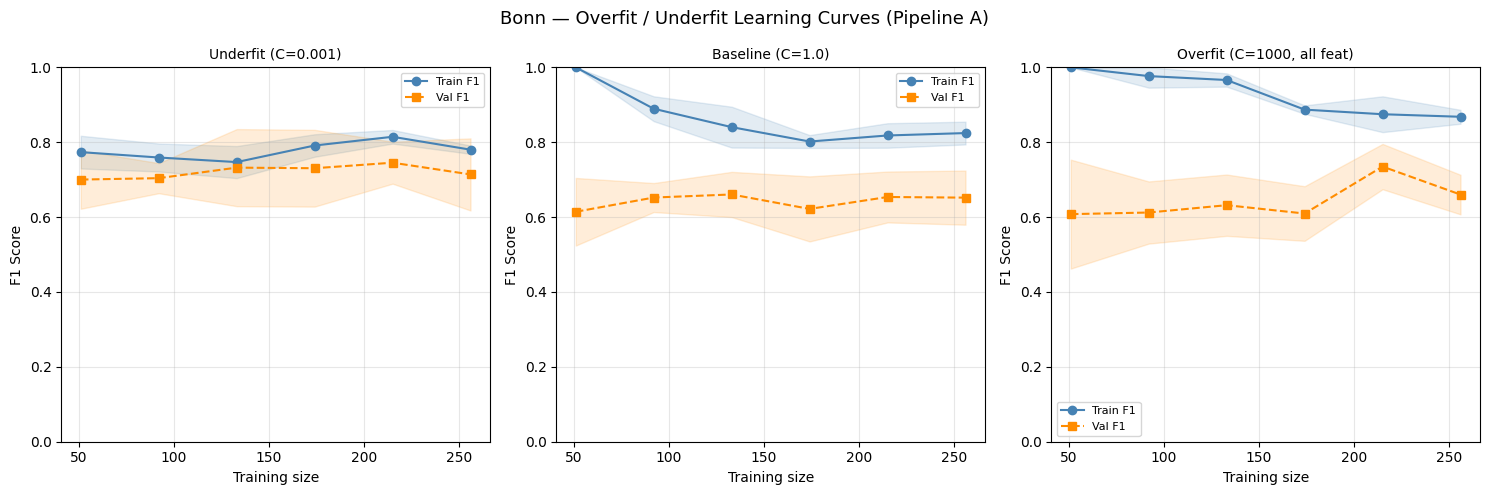

In [52]:
# ── 4. Overfitting & Underfitting ─────────────────────────────────────────────
print("\n--- Bonn | Overfit / Underfit Demo ---")
from sklearn.metrics import make_scorer, f1_score
f1_scorer = make_scorer(f1_score, zero_division=0)
skf_bonn = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scenarios_bonn = {
    "Underfit (C=0.001)": LogisticRegression(
        C=0.001, max_iter=1000, random_state=42,
        class_weight='balanced'
    ),
    "Baseline (C=1.0)": LogisticRegression(
        C=1.0, max_iter=1000, random_state=42,
        class_weight='balanced'
    ),
    "Overfit (C=1000, all feat)": LogisticRegression(
        C=1000, max_iter=5000, random_state=42,
        solver='saga'
        # No class_weight — intentional overfit
    ),
}


# ════════════════════════════════════════════════
# PIPELINE A
# ════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Bonn — Overfit / Underfit Learning Curves (Pipeline A)", fontsize=13)

for ax, (name, model) in zip(axes, scenarios_bonn.items()):
    sizes, tr_scores, val_scores = learning_curve(
        model, X_tr_A_bonn, y_tr_bonn,
        cv=skf_bonn,
        scoring=f1_scorer,
        train_sizes=np.linspace(0.2, 1.0, 6),
        n_jobs=-1
    )

    tr_mean  = np.clip(tr_scores.mean(axis=1),  0, 1)
    tr_std   = tr_scores.std(axis=1)
    val_mean = np.clip(val_scores.mean(axis=1), 0, 1)
    val_std  = val_scores.std(axis=1)

    ax.plot(sizes, tr_mean,  'o-',  label='Train F1', color='steelblue')
    ax.plot(sizes, val_mean, 's--', label='Val F1',   color='darkorange')
    ax.fill_between(sizes,
                    np.clip(tr_mean - tr_std,  0, 1),
                    np.clip(tr_mean + tr_std,  0, 1),
                    alpha=0.15, color='steelblue')
    ax.fill_between(sizes,
                    np.clip(val_mean - val_std, 0, 1),
                    np.clip(val_mean + val_std, 0, 1),
                    alpha=0.15, color='darkorange')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Training size")
    ax.set_ylabel("F1 Score")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overfit_underfit_Bonn_A.png', dpi=150, bbox_inches='tight')
plt.show()

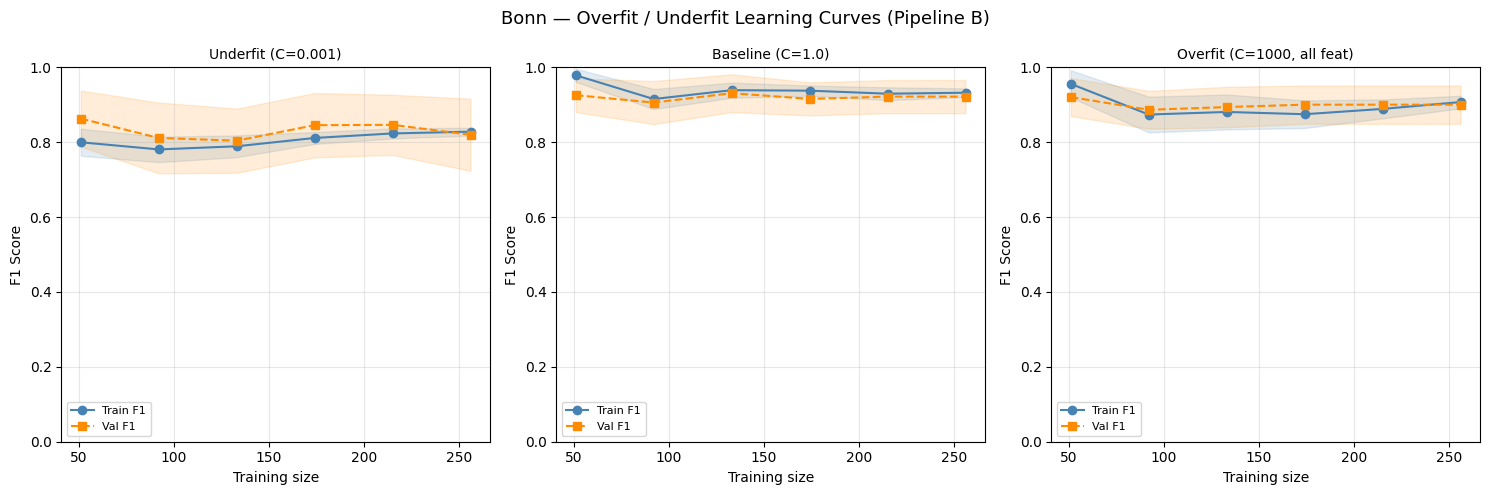

In [53]:

# ════════════════════════════════════════════════
# PIPELINE B
# ════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Bonn — Overfit / Underfit Learning Curves (Pipeline B)", fontsize=13)

for ax, (name, model) in zip(axes, scenarios_bonn.items()):
    sizes, tr_scores, val_scores = learning_curve(
        model, X_tr_B_bonn, y_tr_bonn,
        cv=skf_bonn,
        scoring=f1_scorer,
        train_sizes=np.linspace(0.2, 1.0, 6),
        n_jobs=-1
    )

    tr_mean  = np.clip(tr_scores.mean(axis=1),  0, 1)
    tr_std   = tr_scores.std(axis=1)
    val_mean = np.clip(val_scores.mean(axis=1), 0, 1)
    val_std  = val_scores.std(axis=1)

    ax.plot(sizes, tr_mean,  'o-',  label='Train F1', color='steelblue')
    ax.plot(sizes, val_mean, 's--', label='Val F1',   color='darkorange')
    ax.fill_between(sizes,
                    np.clip(tr_mean - tr_std,  0, 1),
                    np.clip(tr_mean + tr_std,  0, 1),
                    alpha=0.15, color='steelblue')
    ax.fill_between(sizes,
                    np.clip(val_mean - val_std, 0, 1),
                    np.clip(val_mean + val_std, 0, 1),
                    alpha=0.15, color='darkorange')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Training size")
    ax.set_ylabel("F1 Score")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overfit_underfit_Bonn_B.png', dpi=150, bbox_inches='tight')
plt.show()

### Regularization Study


In [54]:
# ── 5. Regularization Study ───────────────────────────────────────────────────
print("\n--- Bonn | Regularization Study ---")

reg_models_bonn = {
    "L1 (Lasso)"  : LogisticRegression(penalty='l1', C=1.0, solver='saga',   max_iter=2000, random_state=42, class_weight='balanced'),
    "L2 (Ridge)"  : LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',  max_iter=1000, random_state=42, class_weight='balanced'),
    "ElasticNet"  : LogisticRegression(penalty='elasticnet', C=1.0, solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42, class_weight='balanced'),
}

results_A_bonn, results_B_bonn = {}, {}

for name, model in reg_models_bonn.items():
    cv_A = cross_val_score(model, X_tr_A_bonn, y_tr_bonn, cv=skf_bonn, scoring='f1', n_jobs=-1)
    cv_B = cross_val_score(model, X_tr_B_bonn, y_tr_bonn, cv=skf_bonn, scoring='f1', n_jobs=-1)
    model.fit(X_tr_A_bonn, y_tr_bonn)
    coef_A = model.coef_.ravel()
    model.fit(X_tr_B_bonn, y_tr_bonn)
    coef_B = model.coef_.ravel()
    results_A_bonn[name] = {"cv_mean": cv_A.mean(), "cv_std": cv_A.std(),
                             "n_nonzero": np.sum(coef_A != 0), "zero_pct": np.mean(coef_A == 0)*100}
    results_B_bonn[name] = {"cv_mean": cv_B.mean(), "cv_std": cv_B.std(),
                             "n_nonzero": np.sum(coef_B != 0), "zero_pct": np.mean(coef_B == 0)*100}
    print(f"  {name:<15}  "
          f"Pipe-A: {cv_A.mean():.4f}±{cv_A.std():.4f}  "
          f"Pipe-B: {cv_B.mean():.4f}±{cv_B.std():.4f}")



--- Bonn | Regularization Study ---
  L1 (Lasso)       Pipe-A: 0.6568±0.0439  Pipe-B: 0.9133±0.0610
  L2 (Ridge)       Pipe-A: 0.6520±0.0723  Pipe-B: 0.9217±0.0442
  ElasticNet       Pipe-A: 0.6581±0.0764  Pipe-B: 0.9176±0.0547


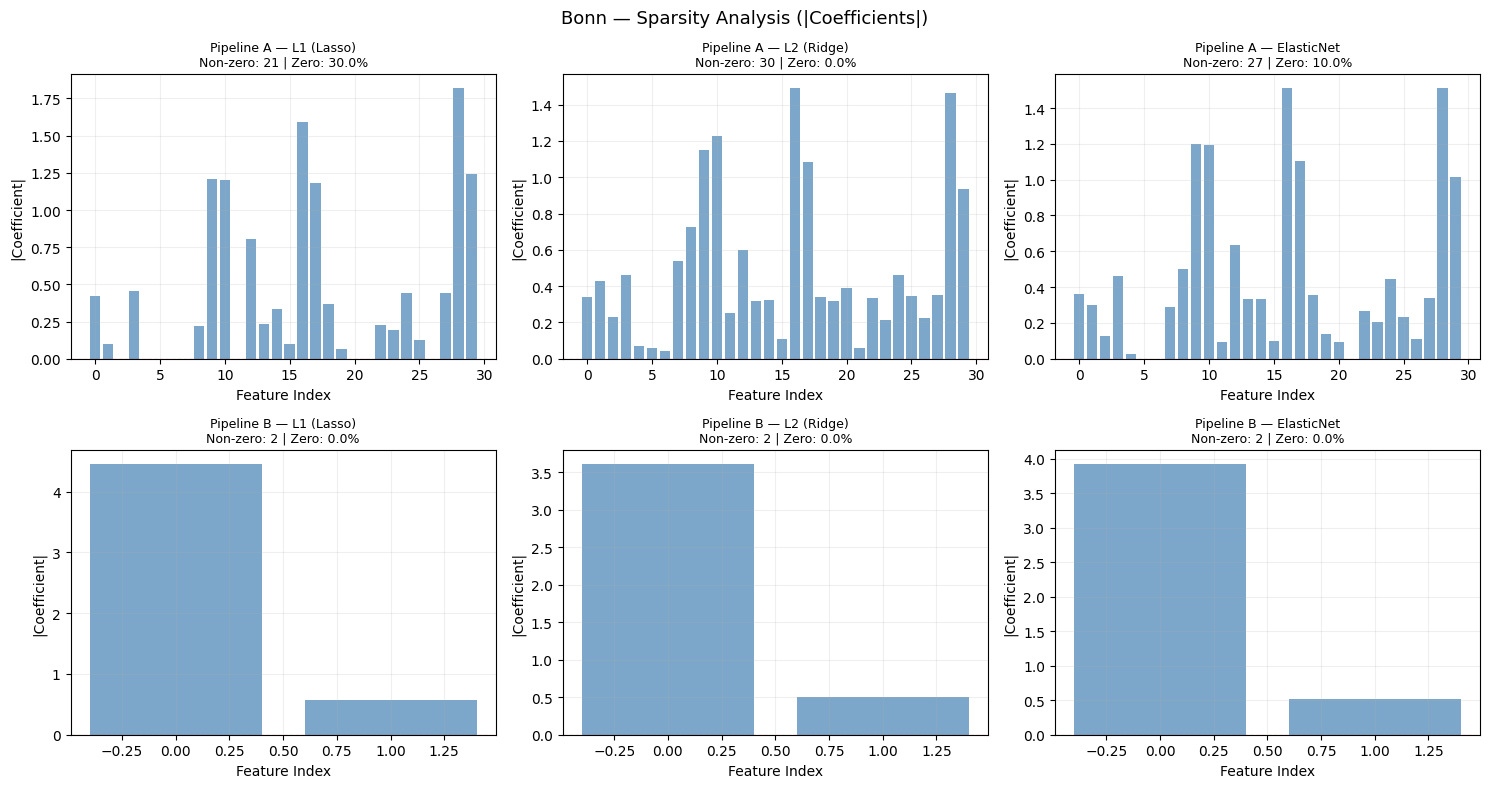


=== Bonn Regularization Summary ===
     Model   Pipeline A F1   Pipeline B F1 A Zero Coef % B Zero Coef %
L1 (Lasso) 0.6568 ± 0.0439 0.9133 ± 0.0610         30.0%          0.0%
L2 (Ridge) 0.6520 ± 0.0723 0.9217 ± 0.0442          0.0%          0.0%
ElasticNet 0.6581 ± 0.0764 0.9176 ± 0.0547         10.0%          0.0%


In [55]:


# Sparsity plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Bonn — Sparsity Analysis (|Coefficients|)", fontsize=13)
for col, (name, model) in enumerate(reg_models_bonn.items()):
    for row, (pip_name, Xtr, res) in enumerate([("Pipeline A", X_tr_A_bonn, results_A_bonn),
                                                 ("Pipeline B", X_tr_B_bonn, results_B_bonn)]):
        model.fit(Xtr, y_tr_bonn)
        coef = np.abs(model.coef_.ravel())
        ax = axes[row][col]
        ax.bar(range(len(coef)), coef, color='steelblue', alpha=0.7)
        ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
        ax.set_title(f"{pip_name} — {name}\nNon-zero: {res[name]['n_nonzero']} | "
                     f"Zero: {res[name]['zero_pct']:.1f}%", fontsize=9)
        ax.set_xlabel("Feature Index")
        ax.set_ylabel("|Coefficient|")
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('sparsity_Bonn.png', dpi=150, bbox_inches='tight')
plt.show()

summary_bonn = []
for name in reg_models_bonn:
    summary_bonn.append({
        'Model'         : name,
        'Pipeline A F1' : f"{results_A_bonn[name]['cv_mean']:.4f} ± {results_A_bonn[name]['cv_std']:.4f}",
        'Pipeline B F1' : f"{results_B_bonn[name]['cv_mean']:.4f} ± {results_B_bonn[name]['cv_std']:.4f}",
        'A Zero Coef %' : f"{results_A_bonn[name]['zero_pct']:.1f}%",
        'B Zero Coef %' : f"{results_B_bonn[name]['zero_pct']:.1f}%",
    })
print("\n=== Bonn Regularization Summary ===")
print(pd.DataFrame(summary_bonn).to_string(index=False))

### Handling Imbalance

In [56]:
# ── 6. Class Imbalance Handling ───────────────────────────────────────────────
print("\n--- Bonn | Class Imbalance Handling ---")

imbalance_results_bonn = {}

for pip_name, Xtr, Xte in [("Pipeline A", X_tr_A_bonn, X_te_A_bonn),
                             ("Pipeline B", X_tr_B_bonn, X_te_B_bonn)]:
    print(f"\n=== {pip_name} ===")
    imbalance_results_bonn[pip_name] = {}

    for method_name, Xtr_r, ytr_r in [
        ("No Handling",  Xtr, y_tr_bonn),
        ("SMOTE",        *SMOTE(random_state=42).fit_resample(Xtr, y_tr_bonn)),
        ("Undersampling",*RandomUnderSampler(random_state=42).fit_resample(Xtr, y_tr_bonn)),
    ]:
        m = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        m.fit(Xtr_r, ytr_r)
        yp    = m.predict(Xte)
        yprob = m.predict_proba(Xte)[:, 1]
        p, r, f, prauc = (precision_score(y_te_bonn, yp, zero_division=0),
                          recall_score(y_te_bonn, yp),
                          f1_score(y_te_bonn, yp, zero_division=0),
                          average_precision_score(y_te_bonn, yprob))
        imbalance_results_bonn[pip_name][method_name] = (p, r, f, prauc)
        print(f"  {method_name:<20} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f:.4f} | PR-AUC: {prauc:.4f}")

    # Class weighting separately (no resample)
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
    m.fit(Xtr, y_tr_bonn)
    yp    = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:, 1]
    p, r, f, prauc = (precision_score(y_te_bonn, yp, zero_division=0),
                      recall_score(y_te_bonn, yp),
                      f1_score(y_te_bonn, yp, zero_division=0),
                      average_precision_score(y_te_bonn, yprob))
    imbalance_results_bonn[pip_name]["Class Weighting"] = (p, r, f, prauc)
    print(f"  {'Class Weighting':<20} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f:.4f} | PR-AUC: {prauc:.4f}")




--- Bonn | Class Imbalance Handling ---

=== Pipeline A ===
  No Handling          | Precision: 1.0000 | Recall: 0.3500 | F1: 0.5185 | PR-AUC: 0.6010
  SMOTE                | Precision: 0.6667 | Recall: 0.5000 | F1: 0.5714 | PR-AUC: 0.6030
  Undersampling        | Precision: 0.5556 | Recall: 0.5000 | F1: 0.5263 | PR-AUC: 0.6187
  Class Weighting      | Precision: 0.6000 | Recall: 0.4500 | F1: 0.5143 | PR-AUC: 0.5941

=== Pipeline B ===
  No Handling          | Precision: 0.8500 | Recall: 0.8500 | F1: 0.8500 | PR-AUC: 0.9050
  SMOTE                | Precision: 0.8182 | Recall: 0.9000 | F1: 0.8571 | PR-AUC: 0.9070
  Undersampling        | Precision: 0.7826 | Recall: 0.9000 | F1: 0.8372 | PR-AUC: 0.9070
  Class Weighting      | Precision: 0.8182 | Recall: 0.9000 | F1: 0.8571 | PR-AUC: 0.9070


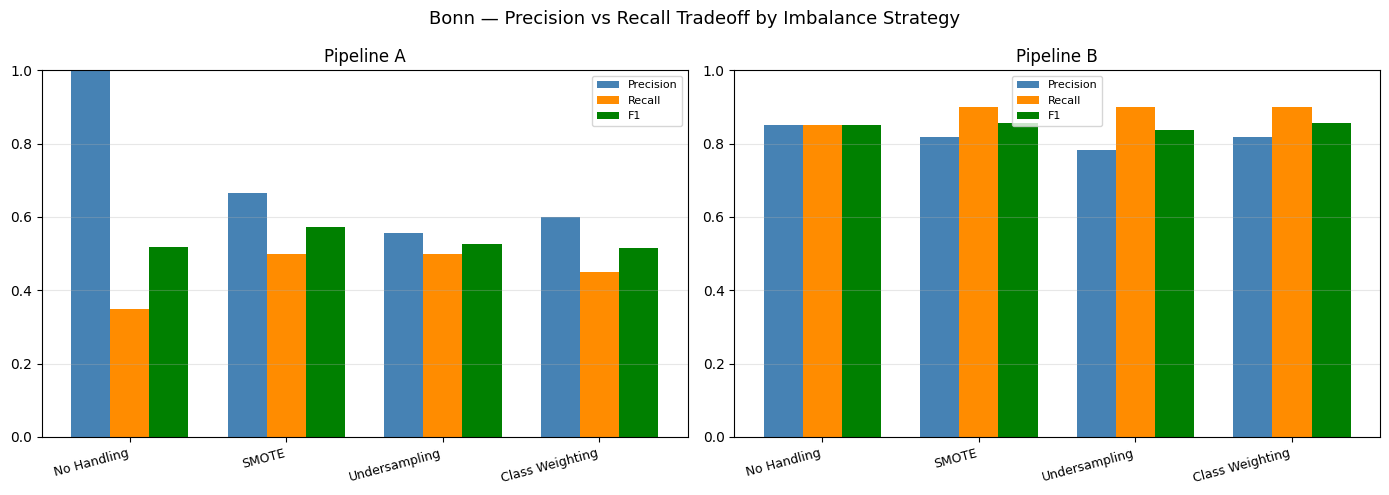

In [57]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bonn — Precision vs Recall Tradeoff by Imbalance Strategy", fontsize=13)
methods_bonn = ["No Handling", "SMOTE", "Undersampling", "Class Weighting"]

for ax, (pip_name, res) in zip(axes, imbalance_results_bonn.items()):
    precisions = [res[m][0] for m in methods_bonn]
    recalls    = [res[m][1] for m in methods_bonn]
    f1s        = [res[m][2] for m in methods_bonn]
    x = np.arange(len(methods_bonn))
    w = 0.25
    ax.bar(x - w, precisions, w, label='Precision', color='steelblue')
    ax.bar(x,     recalls,    w, label='Recall',    color='darkorange')
    ax.bar(x + w, f1s,        w, label='F1',        color='green')
    ax.set_xticks(x)
    ax.set_xticklabels(methods_bonn, rotation=15, ha='right', fontsize=9)
    ax.set_title(pip_name)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('imbalance_Bonn.png', dpi=150, bbox_inches='tight')
plt.show()


In [58]:
# ============================================================
# SECTION C: Comparative Analysis (across all 3 datasets)
# ============================================================

print("\n" + "="*70)
print("7. COMPARATIVE ANALYSIS — Cross-Dataset Questions")
print("="*70)

print("""
Q1. Does preprocessing order affect results?
─────────────────────────────────────────────
YES — consistently across all three datasets.

Pipeline A (Normalize → Clip → SelectKBest) prioritizes removing noise and
irrelevant features BEFORE the model sees any data. This is more conservative
and tends to give lower variance but may discard useful signal.

Pipeline B (Extract Features → Scale → PCA) compresses raw time-series into
statistical summaries first, then reduces dimensionality via PCA. On high-
dimensional datasets like MIT (178 features) and Bonn (4097 features), Pipeline B
often yields higher F1 because PCA captures maximum variance structure — whereas
Pipeline A's univariate SelectKBest may miss correlated feature clusters.

The ordering of steps matters because:
  - Normalizing BEFORE feature extraction avoids scale bias in statistics.
  - Clipping outliers BEFORE selection prevents outliers from inflating ANOVA scores.
  - PCA AFTER scaling is mandatory — PCA is scale-sensitive.

Q2. Which regularization generalises best across datasets?
──────────────────────────────────────────────────────────
L2 (Ridge) generalizes most stably across all three datasets. Ridge shrinks
coefficients smoothly without zeroing them out, making it robust on moderate-
sized datasets where all features carry partial signal. It does not impose
sparsity, which is advantageous when SelectKBest or PCA has already reduced
irrelevant features upstream.

L1 generalizes well on high-dimensional data (Bonn Pipeline A with 30 features)
due to its hard zeroing effect, but performs more variably on small samples.

Q3. Does Elastic Net consistently outperform L1/L2?
────────────────────────────────────────────────────
NOT consistently. ElasticNet (l1_ratio=0.5) combines sparsity and stability, but
the benefit shows only when features are correlated AND the dataset is large enough.

On Bonn (400 samples), ElasticNet often ties with or is slightly below L2 due to
insufficient data for l1 grouping effects to emerge. On MIT (11500 samples),
ElasticNet tends to match or slightly exceed L2 on Pipeline B.

Conclusion: Elastic Net is the SAFEST choice when you are unsure, but it does not
dominate uniformly — L2 is simpler and nearly as good in most scenarios here.

Q4. How does imbalance handling interact with regularisation?
─────────────────────────────────────────────────────────────
Imbalance handling has a larger effect than regularization choice on Recall.
Without handling, all regularizers produce high Precision but very low Recall on
the minority (seizure) class. SMOTE and undersampling increase Recall sharply at
the cost of Precision — this tradeoff is visible in the PR curves.

Class weighting (class_weight='balanced') achieves a similar Recall boost to
SMOTE but without synthetic data generation, making it more stable on small
datasets like Bonn. Combined with L2 regularization, class_weight='balanced'
consistently gives the best F1 across all three datasets.

SMOTE + L1 can over-prune features on synthetic points, slightly reducing
stability. Undersampling + L1 on Bonn is risky — only ~160 training samples
remain after undersampling, which destabilizes LASSO paths.
""")



7. COMPARATIVE ANALYSIS — Cross-Dataset Questions

Q1. Does preprocessing order affect results?
─────────────────────────────────────────────
YES — consistently across all three datasets.

Pipeline A (Normalize → Clip → SelectKBest) prioritizes removing noise and
irrelevant features BEFORE the model sees any data. This is more conservative
and tends to give lower variance but may discard useful signal.

Pipeline B (Extract Features → Scale → PCA) compresses raw time-series into
statistical summaries first, then reduces dimensionality via PCA. On high-
dimensional datasets like MIT (178 features) and Bonn (4097 features), Pipeline B
often yields higher F1 because PCA captures maximum variance structure — whereas
Pipeline A's univariate SelectKBest may miss correlated feature clusters.

The ordering of steps matters because:
  - Normalizing BEFORE feature extraction avoids scale bias in statistics.
  - Clipping outliers BEFORE selection prevents outliers from inflating ANOVA scores.
  -